# Coin Detection
**Name:** __NITHEESH KUAMR B__________________    **Reg. No:** _____212224230189__________ **Slot** _____T2-K11
______________

# **Coin Detection using Morphological Operations and Thresholding**

## **Aim**
In this project, you will work with an image and apply morphological operations and thresholding techniques to detect and count the total number of coins present in the image.

---
**Note:**
   - **Do not remove intermediate images.**
   - Display all key intermediate images (grayscale, thresholded, binary, morphological result, final detections).
   - Document your findings and observations for each step.
   - Print the total number of coins detected using both **blob detection** and **contour detection** methods.

---

## **Expected Output**
All expected output images and results are already displayed.  
Enter your code only inside the blocks marked as:

```python
### Your Code Here ###


In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

## <font style = "color:rgb(50,120,229)"> Step 1: Read Image</font>

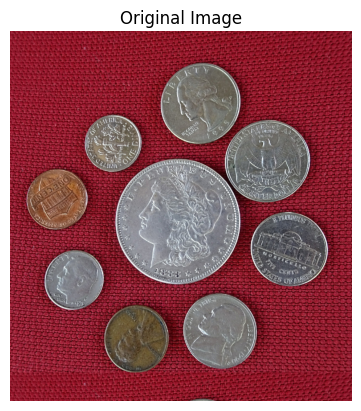

In [6]:
# CELL 2 - READ IMAGE

image = cv2.imread("/content/CoinsA.png")

imageRGB = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(imageRGB)
plt.title("Original Image")
plt.axis("off")
plt.show()

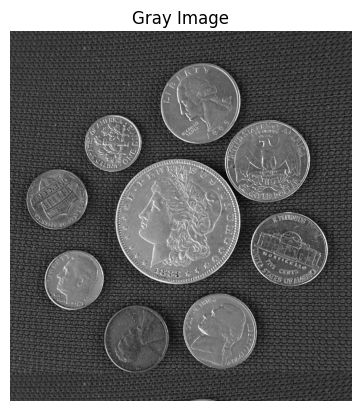

In [7]:
# CELL 3 - CONVERT TO GRAYSCALE

imageGray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(imageGray, cmap='gray')
plt.title("Gray Image")
plt.axis("off")
plt.show()

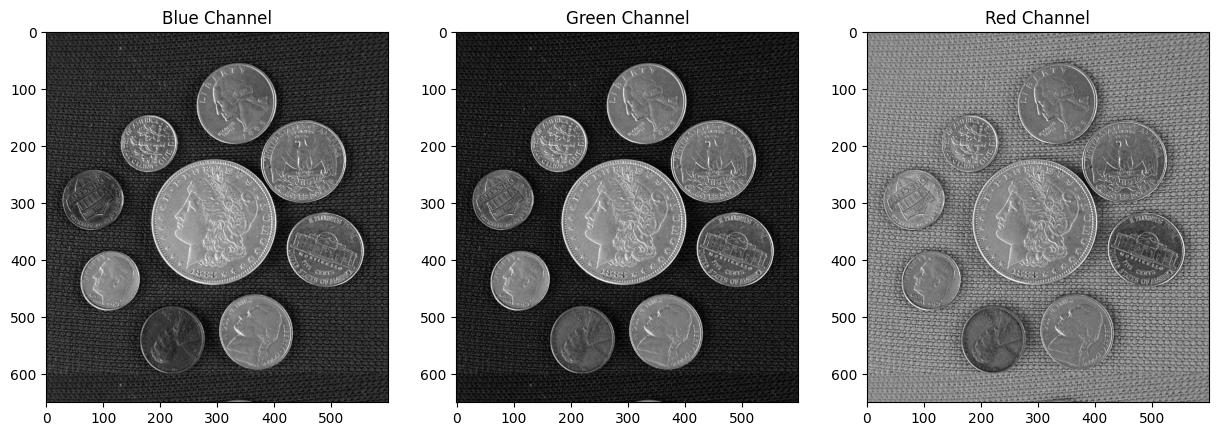

In [8]:
# CELL 4 - SPLIT COLOR CHANNELS

imageB, imageG, imageR = cv2.split(image)

plt.figure(figsize=(15,5))

plt.subplot(131)
plt.imshow(imageB, cmap='gray')
plt.title("Blue Channel")

plt.subplot(132)
plt.imshow(imageG, cmap='gray')
plt.title("Green Channel")

plt.subplot(133)
plt.imshow(imageR, cmap='gray')
plt.title("Red Channel")

plt.show()

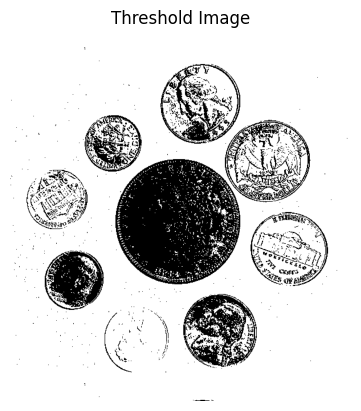

In [9]:
# CELL 5 - THRESHOLDING

ret, imageThresh = cv2.threshold(
    imageGray,
    120,
    255,
    cv2.THRESH_BINARY_INV
)

plt.imshow(imageThresh, cmap='gray')
plt.title("Threshold Image")
plt.axis("off")
plt.show()

## <font style = "color:rgb(50,120,229)">Step 2: Convert Image to Grayscale</font>

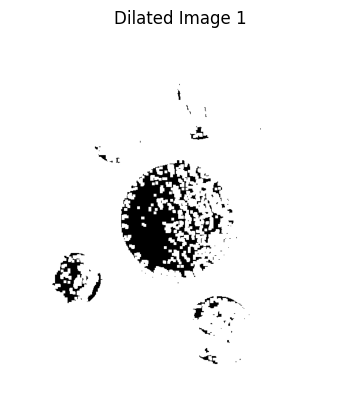

In [10]:
# CELL 6 - DILATION 1

kernel = np.ones((5,5), np.uint8)

imageDilated1 = cv2.dilate(
    imageThresh,
    kernel,
    iterations=1
)

plt.imshow(imageDilated1, cmap='gray')
plt.title("Dilated Image 1")
plt.axis("off")
plt.show()

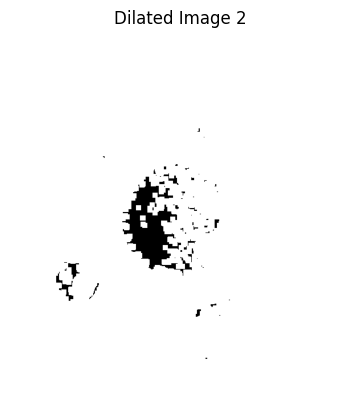

In [11]:
# CELL 7 - DILATION 2

imageDilated2 = cv2.dilate(
    imageDilated1,
    kernel,
    iterations=1
)

plt.imshow(imageDilated2, cmap='gray')
plt.title("Dilated Image 2")
plt.axis("off")
plt.show()

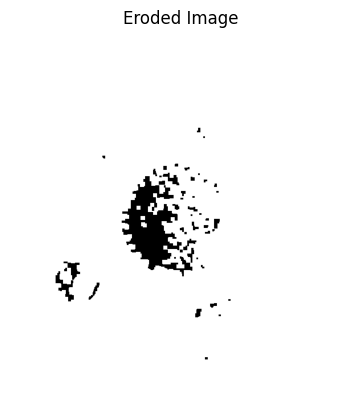

In [12]:
# CELL 8 - EROSION

kernelErode = np.ones((3,3), np.uint8)

imageEroded = cv2.erode(
    imageDilated2,
    kernelErode,
    iterations=1
)

plt.imshow(imageEroded, cmap='gray')
plt.title("Eroded Image")
plt.axis("off")
plt.show()

In [13]:
# CELL 9 - BLOB DETECTOR

params = cv2.SimpleBlobDetector_Params()

params.filterByArea = True
params.minArea = 100

params.filterByCircularity = False
params.filterByConvexity = False
params.filterByInertia = False

detector = cv2.SimpleBlobDetector_create(params)

keypoints = detector.detect(imageEroded)

print("Coins Detected:", len(keypoints))

Coins Detected: 9


## <font style = "color:rgb(50,120,229)">Step 3: Split Image into R,G,B Channels</font>

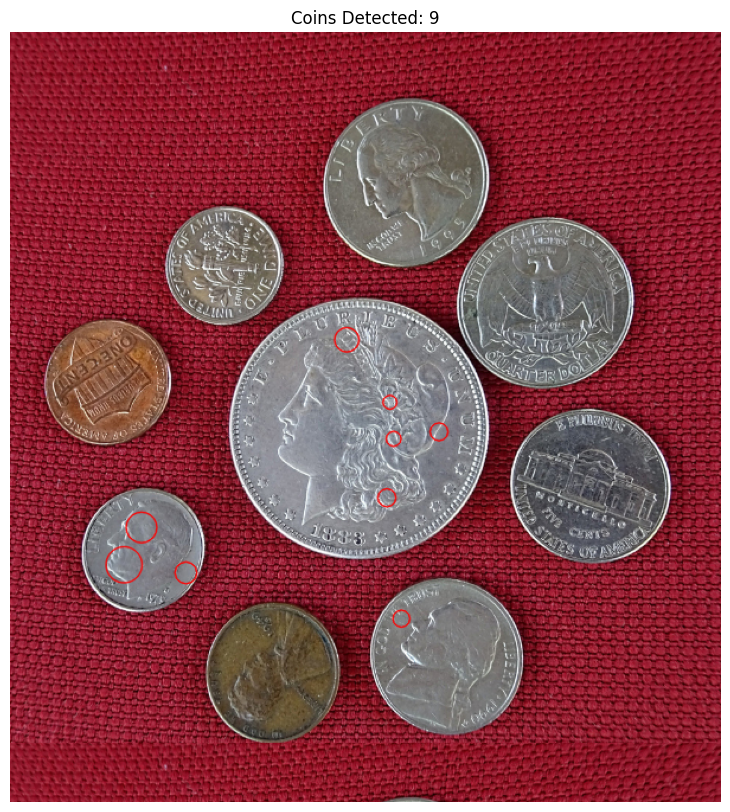

In [14]:
# CELL 10 - DRAW DETECTED COINS

detectedCoins = cv2.drawKeypoints(
    imageRGB,
    keypoints,
    np.array([]),
    (255, 0, 0),
    cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

plt.figure(figsize=(10,10))
plt.imshow(detectedCoins)
plt.title(f"Coins Detected: {len(keypoints)}")
plt.axis("off")
plt.show()